# A Rota da Acadêmica - Mecanismos de Atenção

**Giovani Nagano**

## Introdução

A Torre de Babel é uma narrativa bíblica que, resumidamente, explica a origem dos diferentes idiomas humanos. Segundo o mito, a humanidade compartilhava a mesma língua e, com ela, o poder de realizar grandes feitos. Ao tentar construir uma torre que alcançasse o céu a fim de glorificar a si mesmos, tiveram suas línguas confundidas e se espalharam pelo mundo, devido a incapacidade de se compreender mutuamente. Nessa construção, a diversidade linguística nasceu como uma maldição — um abismo entre os povos.

<div style="text-align: center;">
  <img
    src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/La_Tour_de_Babel%2C_Van_Valckenborch%2C_1594.jpg/1920px-La_Tour_de_Babel%2C_Van_Valckenborch%2C_1594.jpg"
    alt="Torre de Babel"
    style="max-width: 600px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Van Valckenborch - La Tour de Babel, 1594
  </a>
</div>

Sendo um mito ou não, a humanidade passou a reverter essa história: tradutores, dicionários e, mais recentemente, **máquinas capazes de traduzir entre centenas de idiomas** começaram a construir pontes e conectar ainda mais pessoas. O que antes era uma "punição divina", acabou se tornando um desafio técnico formidável.

Mas afinal, como máquinas baseadas em modelos matemáticos que não entendem nada no sentido humano? Como elas podem aprender a traduzir "banco" corretamente para "bank" ou "bench" dependendo do contexto? Como elas sabem que, em uma frase de 50 palavras, o início ainda importa para o final? A resposta está em um mecanismo que, ironicamente, lembra a solução oposta à Torre de Babel: ao invés de separar, ele aprende a focar e conectar. Esse mecanismo chama-se **atenção**.

## O mecanismo de atenção

Antes de tudo, é necessário entender por que o mecanismo de atenção foi criado. Para isso, vamos olhar para o problema que ele resolve: a sequência para sequência (seq2seq). Uma sequência, no contexto de aprendizado de máquina, refere-se a dados cuja ordem dos elementos é crucial para interpretação e previsão. Um modelo de sequência deve aprender a relação entre eventos anteriores para prever o próximo elemento da sequência.

As Redes Neurais Recorrentes (RNNs) são modelos de *deep learning* projetados para lidar com dados sequenciais. Em seu modelo clássico, ela processa uma sequência de *tokens* (a unidade básica de processamento) $x_1, x_2, ..., x_T$ mantendo um estado oculto $h_t$, uma função do estado anterior e da entrada atual:

$$h_t = f(h_{t-1}, x_t) = \text{tanh}(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$$

O novo estado oculto ($h_{t}$) é calculado usando a entrada atual ($x_{t}$) e o estado oculto anterior ($h_{t-1}$), ponderados por pesos ($W$), somados a um viés ($b$) e passados por uma função de ativação, geralmente a $\text{tanh}$.

Já a saída é calculada a partir do estado oculto atual, frequentemente usando $\text{softmax}$ para classificação:

$$y_t = \text{softmax}(W_{hy}h_t + b_y)$$

Em uma aplicação de seq2seq, o esquema mais simples usando um diagrama Encoder-Decoder com duas RNNs, uma para codificar e outra para decodificar.

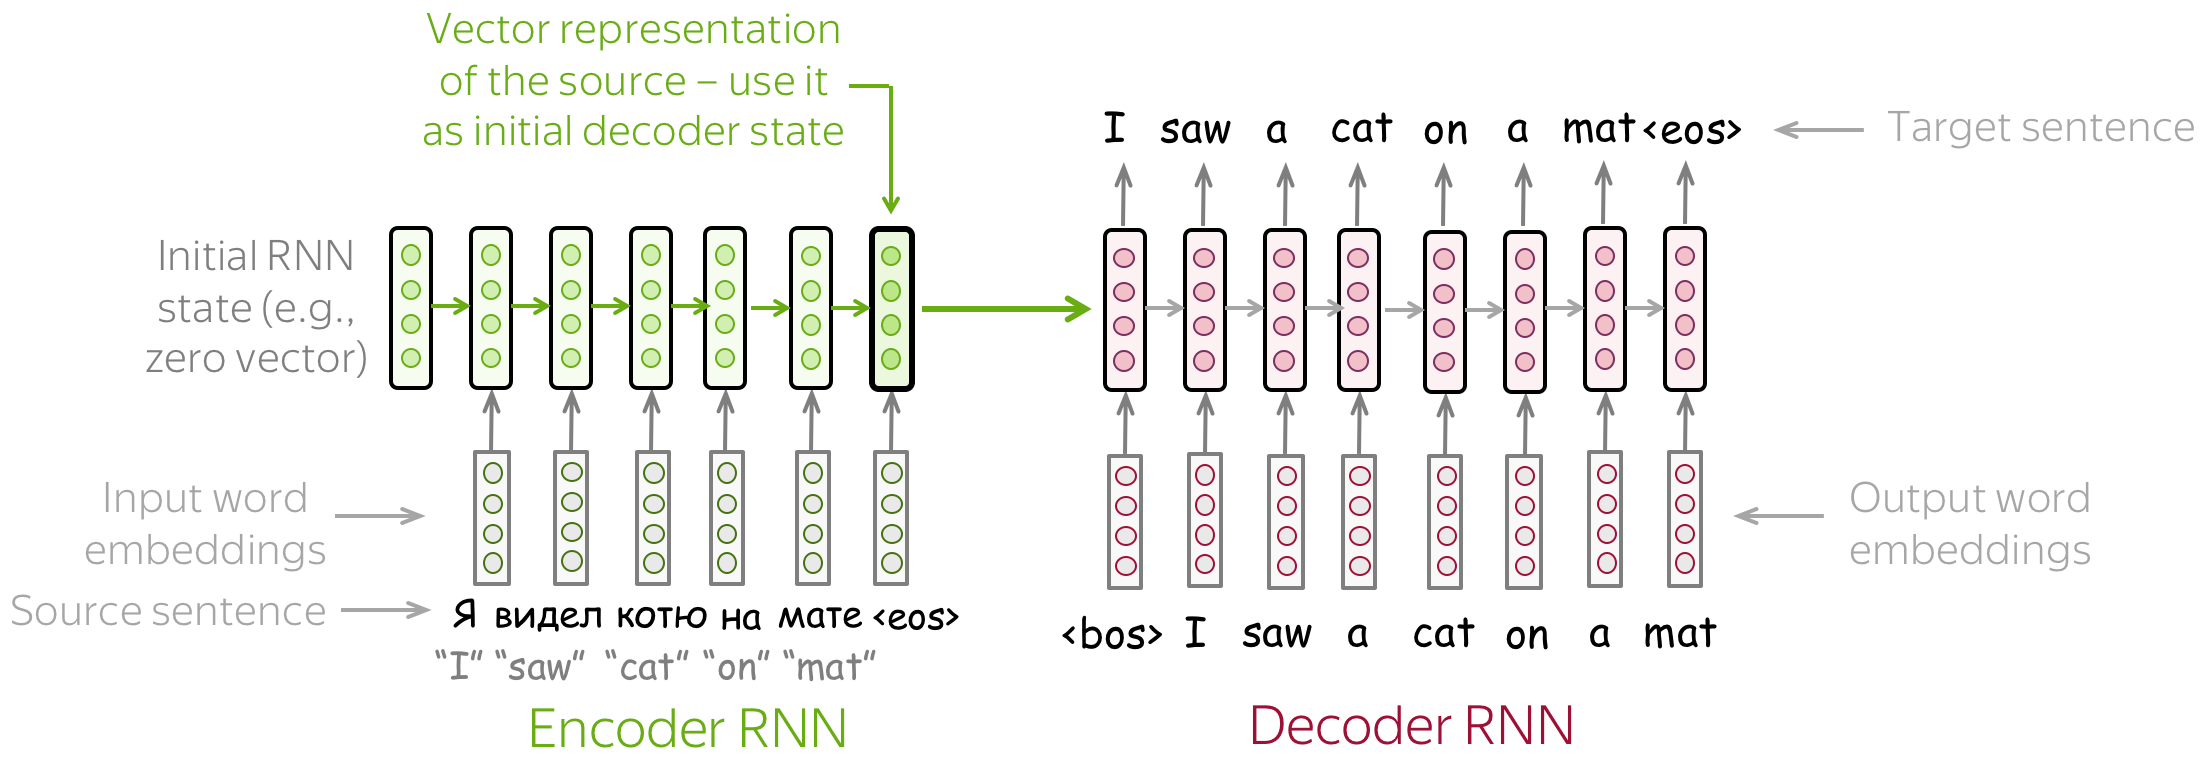

Na imagem, pode-se observar uma representação do modelo, que recebe uma frase. Cada palavra dessa frase é convertida em vetores (*embeddings*), representados pelas caixas cinzas inferiores. Os vetores passam por células de memória (caixas verdes), onde a informação de cada palavra é acumulada da esquerda para a direita. A última saída do encoder representa o vetor de contexto, contendo o resumo semântico da frase original. O lado direito/rosa é responsável por gerar a frase de saída. A geração inicia com a rede prevendo a primeira palavra. Essa palavra gerada torna-se a entrada do próximo passo, alimentando o modelo para gerar a palavra seguinte, e assim sucessivamente até chegar no resultado final.

Voltando às RNNs, ao contrário das redes comun, o treinamento delas ocorre ao "desdobrar" a rede no tempo, isto é, o gradiente da função de perda em um instante $t$ depende não apenas do tempo $t$, mas também dos estados anteriores. Para uma perda no passo $T$ em relação a um parâmetro que afeta o passo 1, tem-se:

$$\frac{\partial L_T}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_T}{\partial h_T} \cdot \left( \prod_{k=t}^{T-1} \frac{\partial h_{k+1}}{\partial h_k} \right) \cdot \frac{\partial h_t}{\partial W}$$

O termo $\frac{\partial h_{k+1}}{\partial h_k}$ é uma matriz jacobiana de pesos vinculada a um produtório. Se seus autovalores são < 1, o produto tende a zero, ocasionando o desaparecimento do gradiente; se > 1, o produto sobe extremamente rápido, causando a explosão do gradiente. Na prática, isso quer dizer que uma RNN tem dificuldade de aprender dependências que exigem lembrar de algo que aconteceu vários passos atrás.

É aí onde entramos no nosso objeto de estudo. A **atenção** propõe uma abordagem radicalmente diferente: ao invés de comprimir a história em um vetor fixo, todos os estados anteriores são mantidos como disponíveis e aprende-se a recuperar seletivamente aqueles que são relevantes.

Diferentemente do modelo seq2seq clássico, que comprime toda a informação em um único vetor estático, o mecanismo de atenção permite que o decodificador consulte dinamicamente todos os estados do encoder a cada momento da geração.

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/attention/computation_scheme-min.png"
    alt="Atenção"
    style="max-width: 600px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention
  </a>
</div>

Conforme ilustrado na imagem, o processo ocorre em quatro etapas principais (de baixo para cima).
1. **Cálculo de *Scores***: para cada passo do decodificador $h_t$, o modelo avalia a relevância de cada estado do encoder $s_k$. Isso é feito através de uma função de pontuação.

2. **Pesos de atenção**: os scores são normalizados via uma função $\text{softmax}$ (a função com exponenciais), garantindo que a soma de todas as relevâncias seja igual a 1. Esses pesos determinam onde o modelo deve focar no texto original para produzir a próxima palavra.

3. **Vetor de contexto**: o vetor de contexto deixa de ser um valor fixo e passa a ser uma soma ponderada (weighted sum) de todos os estados do encoder ($s_1, \dots, s_m$).

4. **Saída de atenção**: esse vetor resultante $c^{(t)}$ é então utilizado pelo decodificador no instante $t$, permitindo que ele enxergue partes específicas da entrada de forma seletiva.

O mecanismo de atenção, como apresentado, foi inicialmente proposto como um acoplamento entre RNNs (Bahdanau et al, 2014). Embora eficaz, essa abordagem ainda herda as limitações das RNNs: o processamento que impede paralelização (isto é, o próximo passo depende da conclusão do passo anterior) e o gargalo representado pela passagem sequencial de informações.

A virada de chave ocorreu em 2017 com o paper *"Attention Is All You Need"* (Vaswani et al.), que propôs uma arquitetura baseada exclusivamente em mecanismos de atenção, eliminando completamente as camadas recorrentes e convolucionais. Essa arquitetura ficou conhecida como **transformer**.

## Transformers

Como dito anteriormente, os **Transformers** inseriram um novo paradigma na modelagem: apenas utilizar a atenção. Em contraste com o modelo apresentado anteriormente e suas variações, essa estrutura, além de apresentar uma qualidade de tradução superior, consegue ser treinada uma ordem de magnitude mais rápida. Na imagem abaixo, observa-se uma comparação entre os modelos e seus métodos de processamento.

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/transformer/modeling_table-min.png"
    alt="Comparação de Modelos"
    style="max-width: 500px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention
  </a>
</div>

Mas afinal, como um Transformer funciona? Enquanto codifica uma frase, as RNNs não vão compreender o que a palavra "banco" por exemplo, até que elas leiam toda a frase. Como foi discutido, isso é um problema em situações onde a entrada é uma sequência longa. Ao contrário disso, os tokens do Transformer interagem um com os outros.

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/transformer/rnn_vs_transformer_river-min.png"
    alt="RNNs vs. Transformers"
    style="max-width: 500px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention
  </a>
</div>

Intuitivamente, o codificador do Transformer pode ser visto como uma sequência de etapas de raciocínio, tal como camadas. Em cada etapa, os tokens interagem entre si - aqui é onde entra a atenção, na forma de autoatenção - trocam informações e tentam se entender melhor no contexto da frase completa. Em cada camada do decodificador, os tokens do prefixo também interagem entre si por meio de um mecanismo de autoatenção, mas, adicionalmente, observam os estados do codificador.

O GIF abaixo ilustra como o Transformer é aplicado. Ele começa gerando representações iniciais (os chamados *embeddings*) para cada palavra. Estas são representadas pelos círculos vazios. Em seguida, usando autoatenção (conceito que será abordado em breve), ele agrega informações de todas as outras palavras, gerando uma nova representação para cada vocábulo, informada por todo o contexto, representada pelas esferas agora preenchidas. Essa etapa é repetida diversas vezes paralelamente para todas as palavras, gerando novas representações sucessivamente.


<div style="text-align: center;">
  <img
    src="https://3.bp.blogspot.com/-aZ3zvPiCoXM/WaiKQO7KRnI/AAAAAAAAB_8/7a1CYjp40nUg4lKpW7covGZJQAySxlg8QCLcBGAs/s640/transform20fps.gif"
    alt="Transformer aplicado em tradução"
    style="max-width: 600px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/' target='_blank'>
    Google Research - Transformer
  </a>
</div>

### Auto-atenção

Iniciando por um dos componentes chaves para o funcionamento do Transformer, a **Autoatenção** (do inglês, *Self-Attention*). A diferença entre a atenção e a autoatenção é que essa opera com base em representações do mesmo tipo, isto é, um elemento "olha" para todos os outros elementos da mesma sequência - incluindo ele próprio - para calcular uma nova representação que incorpora o contexto geral.

Utiliza-se um sistema de atenção baseado em consulta (Q), chave (K) e valor (V) (ou *query*, *key* e *value*). Na prática, isso significa que cada token de entrada recebe três representações que correspondem às funções que ele pode desempenhar.

A consulta (Q) é utilizada quando um token observa outros tokens, procurando por informações para "se entender" melhor. A chave (K) é uma resposta à essa procura: ela é empregada no cálculo dos pesos de atenção. Por fim, o valor (V) é usado para calcular a saída de atenção: ele fornece informações aos tokens que "dizem" que precisam delas, ou seja, atribuíram pesos maiores a esse token.

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/transformer/qkv_explained-min.png"
    alt="Auto-atenção"
    style="max-width: 600px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention
  </a>
</div>

A fórmula para computar a saída da atenção é:

$$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right)V$$

O resultado da multiplicação de Q e a transposta de K é uma pontuação (o já citado score) que indica a afinidade entre o que a palavra atual procura e o que as outras palavras oferecem. Esse valor é dividido pelo fator $\sqrt{d_k}$ para evitar que a função $\text{softmax}$ seja levada a regiões onde ela possui gradientes extremamente pequenos. A junção desses fatores na função $\text{softmax}$ dá os pesos de atenção, que são multiplicados por V, gerando a soma ponderada que ignora o que não é importante e mantém as informações cruciais - pesos baixos e altos, respectivamente.

No decodificador, também há um sistema de autoatenção. Ele é responsável por executar a função de analisar os tokens anteriores. Nessa parte, a autoatenção é um pouco diferente da do codificador. Enquanto o codificador recebe todos os tokens de uma só vez e os tokens podem analisar a todos na frase de entrada, no decodificador, gera-se um token por vez e, durante a geração, não sabemos quais tokens serão gerados no futuro.

Para impedir que o decodificador analise o futuro, o modelo usa autoatenção mascarada: os tokens futuros são mascarados. **Mas como o decodificador pode "analisar o futuro"?** Durante a geração, ele não pode, pois não sabemos o que vem a seguir. Mas no treinamento, usamos traduções de referência, ou seja, que são conhecidas. Portanto, no treinamento, alimentamos a frase alvo completa ao decodificador. Sem máscaras, os tokens "veriam o futuro", e isso não é o que queremos.

### Atenção Multi-Head

Geralmente, entender o papel de uma palavra em uma frase requer compreender como ela se relaciona com as diferentes partes da frase. Isso é importante não apenas no processamento da frase original, mas também na geração da frase alvo. Portanto, precisamos permitir que o modelo se concentre em diferentes aspectos. Essa é a motivação por trás da Atenção Multi-Head. Ao invés de ter um único mecanismo de atenção, a atenção multi-head possui várias "cabeças" que funcionam independentemente.

Formalmente, isso é implementado como a combinação de vários mecanismos de atenção:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ... \text{head}_n)W^O,$$
onde $$\text{head}_i = \text{Attention}(QW_{i}^{Q}, KW_{i}^{K}, VW_{i}^{V})$$

Sendo $W^O$, $W^Q$, $W^K$ e $W^V$ as matrizes de pesos de saída, consulta, chave e valor, respectivamente.

Vamos observar que, na implementação, basta dividir consultas, chaves e valores calculados para uma atenção convencional em várias partes. Dessa maneira, modelos com uma ou várias "cabeças de atenção" têm o mesmo tamanho - a atenção de múltiplas cabeças não aumenta o tamanho do modelo.

## A arquitetura de um Transformer

Agora que compreendemos os principais componentes do modelo e sua ideia geral, vamos olhar diretamente para TODO o modelo. A figura abaixo mostra a arquitetura proposta pelo paper original de Vaswani et al.

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/transformer/model-min.png"
    alt="Arquitetura do Transformer"
    style="max-width: 700px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention, adaptado de Vaswani et al.
  </a>
</div>

Podemos observar alguns conhecidos nossos na imagem e outros que ainda precisam ser introduzidos para enfim estabelecer um transformer de verdade. Intuitivamente, o modelo faz exatamente o que foi discutido anteriormente: no codificador, os tokens se comunicam entre si e atualizam suas representações; no decodificador, um token alvo primeiro observa os tokens alvo gerados anteriormente, depois a fonte e, finalmente, atualiza sua representação. Vamos agora ver com mais detalhes os outros componentes do modelo.

### Blocos feed-forward

Em adição à atenção, cada camada possui um bloco de rede feed-forward: duas camadas lineares com a função não-linear ReLU entre elas:

$$\text{FFN}(x) = \text{max}(0, xW_1 + b_1)W_2 + b_2$$

Depois de ver outros tokens por meio de um mecanismo de atenção, um modelo usa um bloco FFN para processar essa nova informação. Em conclusão:

- Atenção - observar outros tokens e coletar informações;
- FFN - dedicar um momento para pensar e processar essa informação.

### Conexões residuais e normalização de camada

Esses dois componentes fazem parte do mesmo bloco: o *Add & Norm*, que nada mais é que adição e normalização.

As conexões residuais são muito simples, elas adicionam a entrada de um bloco à sua saída. Sua função é facilitar o fluxo de gradiente em uma rede e permitir o empilhamento de muitas camadas. Como você deve imaginar, ela é o *add* do *Add & Norm*.

Já a parte do *norm* do *Add & Norm* denota a normalização de camada. Ela normaliza independentemente a representação vetorial de cada exemplo em lote, cujo objetivo é controlar o "fluxo" para a próxima camada. A normalização de camadas melhora a estabilidade da convergência e, às vezes, até mesmo a qualidade.

### Codificação posicional (Positional encoding)

Talvez você tenha se perguntado: "Mas se esse transformer enxerga todos os tokens de uma só vez e não tem recorrência nem convolução, como ele sabe a ordem dos tokens de entrada?". Pois é, ele não sabe. Para resolver isso, precisamos informar explicitamente ao modelo as posições dos tokens. Para isso, temos dois conjuntos de embeddings: para tokens (esses que já conhecemos) e para posições, o novo maluco no pedaço. Portanto, a representação de entrada de um token é a soma dos dois embeddings: o do token e o posicional.

Os embeddings posicionais podem ser aprendidos, mas os autores descobriram que ter embeddings fixos não prejudica a qualidade. As codificações posicionais fixas usadas no Transformer são:

$$\text{PE}_{pos,2i} = \text{sen}(pos/10000^{2i/d_{modelo}})$$
$$\text{PE}_{pos,2i+1} = \text{cos}(pos/10000^{2i/d_{modelo}})$$

Onde $pos$ é a posição e $i$ é a dimensão do vetor. Cada dimensão da codificação posicional corresponde a uma senoide, e os comprimentos de onda formam uma progressão geométrica de $2 \pi$ a $10000 \cdot 2\pi$.

Sem os embeddings posicionais, o modelo seria incapaz de determinar a ordem dos tokens de entrada.

## Implementação de um Transformer em PyTorch

Depois de muito tempo (muito mesmo) e aprendizado, estamos oficialmente prontos para elaborar um modelo de Transformer em Python, mais precisamente o PyTorch.

Começaremos com as bibliotecas necessárias para o funcionamento do código:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np

Agora, vamos estabelecer nosso mecanismo inicial, a atenção multi-head. Primeiro definimos a classe **`MultiHeadAttention`**, que será uma das bases do nosso modelo.

No método dunder **`__init__`**, o modelo prepara as ferramentas necessárias. O vetor principal `d_modelo` é dividido em várias "cabeças" `num_heads`. Se você tem um vetor de 512 e 8 cabeças, cada cabeça processará um sub-vetor de 64 dimensões ($d_k$). Nele também são criadas quatro camadas lineares ($W_Q, W_K, W_V$ e $W_O$). Elas aprendem a transformar os dados de entrada nos espaços de consulta (query), chave (key) e valor (value).

No próximo método, chamado de **`scaled_dot_product_attention`**, que nada mais é que a fórmula matemática da autoatenção:

$$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right)V$$

Fazemos a fórmula declarando primeiro as pontuações que indicam a afinidade entre o que a palavra atual procura e o que as outras oferecem. Isso é feito com o produto escalar de $Q$ e $K$ transposto dividido por $\sqrt{d_k}$ para evitar problemas com o gradiente. Observe que houver um `mask`, ele define um valor muito baixo para que o modelo ignore palavras como preenchimentos e palavras futuras. Os scores passam pela função $\text{softmax}$, dando pesos/probabilidades para cada palavra. Por fim, há mais uma multiplicação de matrizes entre os pesos e o vetor de valores, gerando um resumo contextualizado.

Abaixo, há dois métodos que irão processar múltiplas "cabeças" de maneira eficiente:

- `dividir_heads`: Reorganiza o tensor, pegando a sequência e a quebra para que cada cabeça de atenção veja apenas a sua parte do vetor.
- `juntar_heads`: Após o cálculo da atenção, ele concatena os resultados de todas as cabeças de volta em um único vetor longo.

Com isso, podemos prosseguir para o método final **`forward`**, que determina o fluxo principal, conectando tudo o que foi declarado anteriormente. Primeiro, os inputs $Q, K, V$ passam pelas camadas lineares e são divididos em múltiplas cabeças. Depois, a função de atenção é aplicada em todas as cabeças ao mesmo tempo. Em último estágio, os resultados são combinados e passam por uma última camada linear responsável por integrar as informações aprendidas por cada cabeça.

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_modelo, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_modelo % num_heads == 0, "d_modelo deve ser divisível por num_heads" 
        """
        O modelo deve receber um número de heads que possa dividir a dimensão do modelo,
        caso contrário, aconteceriam alguns problemas bem tenebrosos lá pra frente
        """ 

        self.d_modelo = d_modelo
        self.num_heads = num_heads
        self.d_k = d_modelo // num_heads
        
        self.W_Q = nn.Linear(d_modelo, d_modelo)
        self.W_K = nn.Linear(d_modelo, d_modelo)
        self.W_V = nn.Linear(d_modelo, d_modelo)
        self.W_O = nn.Linear(d_modelo, d_modelo)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        atencao_scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            atencao_scores = atencao_scores.masked_fill(mask == 0, -1e9)
        atencao_prob = torch.softmax(atencao_scores, dim=-1)
        saida = torch.matmul(atencao_prob, V)
        return saida
        
    def dividir_heads(self, x):
        batch_size, tamanho_seq, d_modelo = x.size()
        return x.view(batch_size, tamanho_seq, self.num_heads, self.d_k).transpose(1, 2)
        
    def juntar_heads(self, x):
        batch_size, _, tamanho_seq, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, tamanho_seq, self.d_modelo)
        
    def forward(self, Q, K, V, mask=None):
        Q = self.dividir_heads(self.W_Q(Q))
        K = self.dividir_heads(self.W_K(K))
        V = self.dividir_heads(self.W_V(V))
        
        atencao_saida = self.scaled_dot_product_attention(Q, K, V, mask)
        saida = self.W_O(self.juntar_heads(atencao_saida))
        return saida

Na próxima célula, declararemos a classe `FeedForward`, que é uma espécie de sanduíche, cujo pão (de cima e o de baixo) são transformações lineares e o recheio é a função ReLU (um nome conhecido de redes neurais). Primeiramente, declara-se as duas funções lineares: a primeira projeta o dado de uma dimensão menor para uma maior; a segunda faz exatamente o processo reverso, voltando à dimensão original. Depois, declara-se a ReLU para "filtrar" o que é importante e o que não é.

A estrutura do Feed-Forward contida no método `forward` segue o princípio da ilustração abaixo:

<div style="text-align: center;">
  <img
    src="https://lena-voita.github.io/resources/lectures/seq2seq/transformer/ffn-min.png"
    alt="Estrutura do Feed-Forward"
    style="max-width: 300px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html' target='_blank'>
    Lena Voita - Seq2seq and Attention
  </a>
</div>

In [3]:
class FeedForward(nn.Module):
    def __init__(self, d_modelo, d_ff):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(d_modelo, d_ff)
        self.fc2 = nn.Linear(d_ff, d_modelo)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

Agora vamos implementar uma das almas do modelo: o conceito dos embeddings posicionais. Como já foi discutido, sem eles o modelo não tem senso de direção e ordem. Iniciamos declarando a classe `EncodingPosicional` e declarando no começo as variáveis `pos`, `posicao` e `termo_div`. Deixando a primeira para o final, a `posicao` é um contador simples de $0$ até o tamanho máximo da frase ($0, 1, 2, 3...$); o `termo_div` é um fator de escala baseado em frequências que garante que cada dimensão do vetor mude em uma velocidade diferente.

A variável `pos` é a estrutura final. Ela começa como uma matriz cheia de zeros que será preenchida com as ondas de seno e cosseno, permitindo que o modelo "saiba" em qual parte da frase ele está apenas olhando para o padrão de ativação dessas ondas. O `register_buffer` ao final diz ao modelo para guardar a matriz `pos`, mas não tentar treinar ela, uma vez que o Encoding Posicional é fixo.

Ao final, pega-se os dados de entrada x - as palavras transformadas em números no formato de embeddings - e soma o mapa de posições. Assim, cada vetor de palavra agora possui uma "coordenada" que diz ao modelo onde ela estava originalmente.

In [4]:
class EncodingPosicional(nn.Module):
    def __init__(self, d_modelo, max_tamanho_seq):
        super(EncodingPosicional, self).__init__()
        
        pos = torch.zeros(max_tamanho_seq, d_modelo)
        posicao = torch.arange(0, max_tamanho_seq, dtype=torch.float).unsqueeze(1)
        termo_div = torch.exp(torch.arange(0, d_modelo, 2).float() * -(np.log(10000.0) / d_modelo))
        
        pos[:, 0::2] = torch.sin(posicao * termo_div)
        pos[:, 1::2] = torch.cos(posicao * termo_div)
        
        self.register_buffer('pos', pos.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pos[:, :x.size(1)]

Agora vamos passar de fato para as camadas presentes na arquitetura do transformer, começando pelo Encoder. No paper original, ele é assim:

<div style="text-align: center;">
  <img
    src="https://miro.medium.com/v2/resize:fit:552/format:webp/0*bPKV4ekQr9ZjYkWJ.png"
    alt="Camada de Encoder"
    style="max-width: 200px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://arxiv.org/pdf/1706.03762' target='_blank'>
    Vaswani et al. - Attention Is All You Need
  </a>
</div>

Começamos declarando a classe e chamamos duas das classes que foram criadas anteriormente: `MultiHeadAttention` para a auto-atenção; e `FeedForward` para o bloco de feed-forward. Além disso, são declaradas duas camadas de normalização (`norm1` e `norm2`), além do dropout, técnica de regularização que desliga aleatoriamente alguns neurônios durante o treino para evitar que o modelo decore os dados.

Com essas ferramentas, basta colocar na ordem do esquema do paper: primeiro os dados chegam no mecanismo de autoatenção. Note que passou-se `x` três vezes (para Q, K e V), por isso autoatenção. Posteriormente, essa saída passa pelo dropout e se soma o resultado de volta a `x` (conexão residual), estamos portanto somando o que foi aprendido de novo e somando com o que já se sabia. Essa soma é normalizada no pelo primeiro normalizador de camada, completando assim o bloco "*Add & Norm*".

Esse novo `x` refinado agora vai passar pela rede `FeedForward`. Novamente aplica-se dropout no output da classe `FeedForward` e somamos com o `x` do passo anterior, estabelecendo mais uma conexão residual. Finalizamos o processo aplicando a segunda normalização e devolvemos `x`.

In [5]:
class CamadaEncoder(nn.Module):
    def __init__(self, d_modelo, num_heads, d_ff, dropout):
        super(CamadaEncoder, self).__init__()
        self.autoatencao = MultiHeadAttention(d_modelo, num_heads)
        self.feed_forward = FeedForward(d_modelo, d_ff)
        self.norm1 = nn.LayerNorm(d_modelo)
        self.norm2 = nn.LayerNorm(d_modelo)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        atencao_saida = self.autoatencao(x, x, x, mask)
        x = self.norm1(x + self.dropout(atencao_saida))
        saida_ff = self.feed_forward(x)
        x = self.norm2(x + self.dropout(saida_ff))
        return x

Passando agora para a camada Decoder, temos o seguinte esquema:

<div style="text-align: center;">
  <img
    src="https://miro.medium.com/v2/resize:fit:552/format:webp/0*SPZgT4k8GQi37H__.png"
    alt="Camada de Encoder"
    style="max-width: 200px; width: 100%; height: auto;"
  >
</div>
 
<div style='text-align: center; margin-top: 10px; font-size: 0.9em; color: #555'>
  Fonte:
  <a href='https://arxiv.org/pdf/1706.03762' target='_blank'>
    Vaswani et al. - Attention Is All You Need
  </a>
</div>

De imediato, percebe-se que essa camada possui a introdução de uma nova etapa, a atenção cruzada. Declara-se as já utilizadas autoatenção e feed-forward, junto delas, a atenção cruzada, que também é uma instância da classe `MultiHeadAttention`. Depois, estabelece-se as três camadas de normalização e o dropout, assim como na camada do encoder.

Para montar o fluxo, começamos igual ao `CamadaEncoder`: os dados chegam no mecanismo de autoatenção, tendo `x` em Q, K e V. O termo `alvo_mask` impede que o modelo "preveja o futuro", garantindo que a palavra na posição $t$ só possa olhar para as palavras nas posições $t-1, t-2, ...$, ele será visto novamente quando o transformer for estabelecido. O `x` é atualizado passando pelo processo de "*Add & Norm*".

Esse novo `x` vai entrar em uma nova saída, baseada dessa vez na atenção cruzada. Observe os argumentos: a consulta (Q) vem do `x`, o que o decoder está processando no momento; já a chave (K) e o valor (V) vêm da saída do encoder, isto é, do resumo da frase original. Basicamente, o decoder usa suas próprias palavras como perguntas para extrair as respostas certas da memória do encoder. Após isso, há mais uma camada de "*Add & Norm*" e repete-se o passo da incorporação do feed-forward e de mais uma etapa de *Add & Norm*. Com isso, concluímos as duas camadas, de encoder e decoder, e estamos prontos para criar nosso transformer.

In [6]:
class CamadaDecoder(nn.Module):
    def __init__(self, d_modelo, num_heads, d_ff, dropout):
        super(CamadaDecoder, self).__init__()
        self.autoatencao = MultiHeadAttention(d_modelo, num_heads)
        self.atencao_cruzada = MultiHeadAttention(d_modelo, num_heads)
        self.feed_forward = FeedForward(d_modelo, d_ff)
        self.norm1 = nn.LayerNorm(d_modelo)
        self.norm2 = nn.LayerNorm(d_modelo)
        self.norm3 = nn.LayerNorm(d_modelo)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, saida_encoder, fonte_mask, alvo_mask):
        atencao_saida = self.autoatencao(x, x, x, alvo_mask)
        x = self.norm1(x + self.dropout(atencao_saida))
        atencao_saida = self.atencao_cruzada(x, saida_encoder, saida_encoder, fonte_mask)
        x = self.norm2(x + self.dropout(atencao_saida))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

Finalmente, após juntar as joias do infinito, é hora de uní-las na nossa manopla: o transformer! Para começar, a classe precisa de algumas entradas para começar:

- `fonte_tamanho_vocab`: Refere-se ao número total de palavras únicas no idioma de origem. Define o tamanho da matriz de embedding do Encoder.
- `alvo_tamanho_vocab`: Relativo ao número total de palavras únicas no idioma de destino. Define o tamanho da matriz de embedding do Decoder e da camada linear final.
- `d_modelo`: É a dimensão de representação interna do modelo.
- `num_heads`: É o número de "cabeças" no Multi-Head Attention.
- `num_camadas`: Refere-se a quantas vezes o bloco do Encoder e do Decoder serão repetidos.
- `d_ff`: Simboliza a dimensão interna do bloco feed-forward. Geralmente é 4 vezes o valor de `d_modelo`.
- `max_tamanho_seq`: Nada mais é que o comprimento máximo das frases que o modelo pode aceitar. Isso é usado para construir a matriz fixa de Encoding Posicional.
- `dropout`: Já comentado antes, é a probabilidade de desligar neurônios aleatoriamente durante o treino para evitar que o modelo "decore" as frases em vez de aprender as regras. 

Tendo descrito as entradas, podemos iniciar a arquitetura da classe. Primeiramente, o método `Embedding` do PyTorch transforma números inteiros (os IDs das palavras) em vetores densos de tamanho `d_modelo`. Logo em seguida, instancia-se a classe `EncodingPosicional` para injetar a noção de ordem nos vetores. Após isso, o `ModuleList` vai armazenar as $N$ camadas do encoder e do decoder. É importante ressaltar que ele é utilizado pois o PyTorch não encontraria os parâmetros das camadas para atualizar durante o treino em uma lista comum. Ao fim dessa parte inicial, declara-se a camada linear de saída que projeta o vetor final de volta para o tamanho do vocabulário, juntamente do dropout.

O próximo método da classe trata da criação dos filtros para que o modelo não olhe para onde não deve: as masks (ou máscaras, para os mais íntimos). Primeiramente, na variável `fonte_mask` é criada uma máscara booleana onde tudo que não é o token de preenchimento é `True` que, junto do `unsqueeze`, que ajusta as dimensões para que a máscara se alinhe com o formato exigido pela atenção. A mesma lógica é usada para o `alvo_mask`. Após determinar o tamanho da sequência com o `.size()`, é criada uma matriz triangular inferior na variável `nopeak_mask`. Ela impede que o Decoder veja o futuro. Exemplo: na posição 2, ele só pode ver as posições 0, 1 e 2, sem deixar o modelo ver algo posterior a isso. Para completar o método, utiliza-se um *and* lógico por meio do operador `&` que combina a máscara de preenchimento com a máscara causal.

Agora vamos para a etapa final do estabelecimento de nossa classe. O fluxo inicia com o cálculo das máscaras necessárias para a entrada e a saída atual, juntamente com a conversão dos IDs em vetores; adição dos embeddings posicionais e a aplicação do dropout. Passamos agora para a execução da pilha de encoder, onde o dado atravessa cada uma das 6 camadas e cada uma delas refina a representação baseada no contexto. Logo após isso, temos a execução da pilha de decoder, onde o decoder recebe sua própria entrada e o contexto da frase original (por meio do `saida_encoder`). Para finalizar, a última predição, chamada de `saida`, transforma os vetores processados em probabilidades sobre o vocabulário de saída. Se o modelo está gerando a próxima palavra, o maior valor indica qual palavra ele escolheu.

In [7]:
class Transformer(nn.Module):
    def __init__(self, fonte_tamanho_vocab, alvo_tamanho_vocab, d_modelo, num_heads, num_camadas, d_ff, max_tamanho_seq, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(fonte_tamanho_vocab, d_modelo)
        self.decoder_embedding = nn.Embedding(alvo_tamanho_vocab, d_modelo)
        self.encoding_posicional = EncodingPosicional(d_modelo, max_tamanho_seq)

        self.encoder_camadas = nn.ModuleList([CamadaEncoder(d_modelo, num_heads, d_ff, dropout) for _ in range(num_camadas)])
        self.decoder_camadas = nn.ModuleList([CamadaDecoder(d_modelo, num_heads, d_ff, dropout) for _ in range(num_camadas)])

        self.fc = nn.Linear(d_modelo, alvo_tamanho_vocab)
        self.dropout = nn.Dropout(dropout)

    def gera_mask(self, fonte, alvo):
        fonte_mask = (fonte != 0).unsqueeze(1).unsqueeze(2)
        alvo_mask = (alvo != 0).unsqueeze(1).unsqueeze(3)
        tamanho_seq = alvo.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, tamanho_seq, tamanho_seq), diagonal=1)).bool()
        alvo_mask = alvo_mask & nopeak_mask
        return fonte_mask, alvo_mask

    def forward(self, fonte, alvo):
        fonte_mask, alvo_mask = self.gera_mask(fonte, alvo)
        fonte_embedded = self.dropout(self.encoding_posicional(self.encoder_embedding(fonte)))
        alvo_embedded = self.dropout(self.encoding_posicional(self.decoder_embedding(alvo)))

        saida_encoder = fonte_embedded
        for enc_layer in self.encoder_camadas:
            saida_encoder = enc_layer(saida_encoder, fonte_mask)

        saida_decoder = alvo_embedded
        for dec_layer in self.decoder_camadas:
            saida_decoder = dec_layer(saida_decoder, saida_encoder, fonte_mask, alvo_mask)

        saida = self.fc(saida_decoder)
        return saida

Agora, para ver nosso bichão trabalhando, precisamos estabelecer os parâmetros. A maioria deles foi escolhida baseando no paper de introdução ao modelo transformer de 2017. O artigo original também utilizava valores de 512 para a dimensionalidade da entrada e da saída, 2048 para a dimensionalidade do bloco de feed-forward, 8 para o número de cabeças, 6 para o número de camadas de encoder e decoder, além da taxa de dropout de 10%. O tamanho do vocabulário foi escolhido visando o equilíbrio: é pequeno o suficiente para o treinamento convergir rápido, mas cobre as palavras mais frequentes de qualquer idioma.

Declaramos o transformer e geramos os dados de amostra dentro de um batch de 64 frases com 100 palavras cada.

In [ ]:
FONTE_TAMANHO_VOCAB = 5000
ALVO_TAMANHO_VOCAB = 5000
D_MODELO = 512
NUM_HEADS = 8
NUM_CAMADAS = 6
D_FF = 2048
MAX_TAMANHO_SEQ = 100
DROPOUT = 0.1

transformer = Transformer(FONTE_TAMANHO_VOCAB, ALVO_TAMANHO_VOCAB, D_MODELO, NUM_HEADS, NUM_CAMADAS, D_FF, MAX_TAMANHO_SEQ, DROPOUT)

# gera dados de amostra aleatoriamente
dados_fonte = torch.randint(1, FONTE_TAMANHO_VOCAB, (64, MAX_TAMANHO_SEQ))  # (batch_size, tamanho_seq)
dados_alvo = torch.randint(1, ALVO_TAMANHO_VOCAB, (64, MAX_TAMANHO_SEQ))  # (batch_size, tamanho_seq)

Tendo tudo pronto, podemos treinar nosso modelo agora. O próximo bloco de código é o ciclo de treinamento. O modelo vai tentar prever a próxima palavra, errar, e ajustar seus pesos internos para não errar da mesma forma na próxima vez.

Declara-se a função de perda, isto é, que vai calcular a distância entre a previsão do modelo e a palavra real; e o otimizador, que será responsável por ajustar os pesos. Posteriormente, o modelo é colocado em "modo de treino", ativando componentes como o dropout, por exemplo. Por fim, estabelece-se um laço que diz que modelo verá o conjunto de dados 100 vezes para tentar memorizar possíveis padrões.

Linha por linha, o laço inicia com um comando para limpar os gradientes do passo anterior, evitando o acúmulo de erros. Depois, passamos a frase de origem e a frase de destino com exceção da última palavra, com o modelo tentando prever o que vem a seguir. Em seguida, comparamos a previsão com a realidade e calculamos como cada peso do modelo contribuiu para o erro final. Por fim, o otimizador efetivamente altera os pesos do transformer para reduzir a perda no próximo passo e a perda é printada junto da época relativa ao valor da perda.

In [9]:
fun_perda = nn.CrossEntropyLoss(ignore_index=0)
otimizador = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()

for epoca in range(100):
    otimizador.zero_grad()
    saida = transformer(dados_fonte, dados_alvo[:, :-1])
    perda = fun_perda(saida.contiguous().view(-1, ALVO_TAMANHO_VOCAB), dados_alvo[:, 1:].contiguous().view(-1))
    perda.backward()
    otimizador.step()
    print(f"Época: {epoca+1}, Perda: {perda.item()}")

Época: 1, Perda: 8.683399200439453
Época: 2, Perda: 8.545003890991211
Época: 3, Perda: 8.479151725769043
Época: 4, Perda: 8.42822551727295
Época: 5, Perda: 8.36830997467041
Época: 6, Perda: 8.302327156066895
Época: 7, Perda: 8.22736930847168
Época: 8, Perda: 8.136576652526855
Época: 9, Perda: 8.056729316711426
Época: 10, Perda: 7.97770357131958
Época: 11, Perda: 7.906330585479736
Época: 12, Perda: 7.822627544403076
Época: 13, Perda: 7.732866287231445
Época: 14, Perda: 7.652535438537598
Época: 15, Perda: 7.574432849884033
Época: 16, Perda: 7.488908767700195
Época: 17, Perda: 7.405461311340332
Época: 18, Perda: 7.3196120262146
Época: 19, Perda: 7.234592437744141
Época: 20, Perda: 7.152835845947266
Época: 21, Perda: 7.076639652252197
Época: 22, Perda: 7.001955509185791
Época: 23, Perda: 6.930264949798584
Época: 24, Perda: 6.838789939880371
Época: 25, Perda: 6.76694917678833
Época: 26, Perda: 6.688564300537109
Época: 27, Perda: 6.62345027923584
Época: 28, Perda: 6.543148994445801
Época: 29

Esse resultado mostra que o transformer está funcionando e a perda está caindo de maneira monotônica, indicando um bom ajuste da taxa de aprendizado. Com a perda chegando em $2.75$, o modelo já não está mais chutando pois ele começou a identificar padrões estatísticos e a certeza dele sobre a próxima palavra aumentou significativamente. Como exercício futuro, seria interessante substituir os dados aleatórios por um dataset real para ver o modelo gerar frases com sentido humano.

## Referências

J. Bittencourt Junior. Mecanismos de Atenção. https://ww2.inf.ufg.br/~anderson/deeplearning/20181/mecanismos_de_atencao_redes_neurais_profundas_deep_learning.pdf

E. Voita. Sequence to Sequence (seq2seq) and Attention. https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html

D. Bahdanau, K. Cho, Y. Bengio. Neural machine translation by jointly learning to align and translate. arXiv preprint arXiv:1409.0473, 2014. https://arxiv.org/pdf/1409.0473

A. Vaswani et al. Attention is all you need. Advances in neural information processing systems, v. 30, 2017. https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf

J. Uszkoreit. Transformer: A Novel Neural Network Architecture for Language Understanding. https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/

A. Sarkar. Build your own Transformer from scratch using Pytorch. https://medium.com/data-science/build-your-own-transformer-from-scratch-using-pytorch-84c850470dcb